# 01 · Problem framing & the skill as data

**Execution status:** 🟢 EXECUTED (CPU, outputs saved)
**Plan reference:** PLAN Part I (RQs) · Part II (data design) · PREREG §2–§3

Two jobs. First, state the eight research questions as **falsifiable** claims with frozen decision rules — the contract the rest of the study is held to. Second, treat the *independent variable itself* — the design skill — as data: parse its five components and five render-inert fillers, run every build-time audit live, and show that all 24 experimental cells carry **constant prompt mass** so any effect is content, not length. Then the 58-prompt corpus.

| | |
|---|---|
| **Inputs** | `research/skill_exemplars/canonical_skill_v1.md`, `config/cells.yaml`, `config/prompts.yaml` |
| **Outputs** | audit report, 24-cell mass table, corpus EDA figures |
| **Runtime** | < 20 s (uses the cached Qwen tokenizer — permitted; no model weights) |

*Project 19 — Anatomy of a Design Skill. Governance: `CLAUDE.md`. Plan: `PLAN.md`. Derivations:
`THEORY.md`. Freeze: `PREREGISTRATION.md`. This notebook imports tested machinery from the `p19`
package and carries the narrative; it never re-implements logic that lives in `src/p19/`.*

In [1]:
%matplotlib inline
# Bootstrap: locate the repo root (repo-relative — no hardcoded paths) and make p19 importable.
import sys, pathlib
_here = pathlib.Path.cwd()
_root = next((c for c in [_here, *_here.parents]
              if (c / "pyproject.toml").exists() and (c / "src" / "p19").exists()), _here)
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from p19 import REPO_ROOT
np.random.seed(0)                      # notebook-level seed; every generator also takes an explicit seed
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 120)
print("p19 ready · repo:", REPO_ROOT.name)

p19 ready · repo: steering-llm-aesthetics


## §I · Problem framing — eight falsifiable questions

A research question is only worth asking if a specific result would change your mind. Each RQ below
pairs a hypothesis with a **preregistered decision rule** (frozen in `PREREGISTRATION.md` before any
GPU run) and an explicit **honest-null branch**. Freezing the rules first is what separates a
confirmatory study from a fishing expedition.

In [2]:
# The confirmatory decision rules, verbatim in structure from PREREG §4 (the study's contract).
import pandas as pd
rules = pd.DataFrame([
 ["H-skill","FULL ≻ NEUTRAL on both signals","non-null per oracle; report δ and %-gap","the skill works & it is content, not prompt mass"],
 ["RQ1 necessity","μ(FULL)−μ(LOO-Cᵢ)>0","Holm over 5 LOO on POC OR gated BT CI>0; rank by δ","C5, C1 expected largest"],
 ["RQ2 sufficiency","μ(AOI-Cᵢ)−μ(NEUTRAL)>0, <FULL","Holm over 5 AOI; distributed if none ≥30% gap","sufficiency is distributed"],
 ["RQ3 interactions","≥1 non-zero 2FI","BH over 10 2FIs; concordant on ≥1 family","a few super/sub-additive pairs"],
 ["RQ4 nudge","FULL>BEAUTY1>NEUTRAL","content if FULL−BEAUTY1>0; nudge if BEAUTY1≥70% gap","391 tokens beat 5 words?"],
 ["RQ5 locate","mid-band linear signal","AUC≥.80 & sel≥.15 & patch≥25%, contiguous","band ≈ layers 11–20"],
 ["RQ6 steer","no-prompt steering raises held-out quality","§7 success criterion (4 conjuncts)","the hard bar"],
 ["RQ7 failure","OOD-generalizes, anti-steer<50%","BH per task type","robust / partial / brittle"],
 ["RQ8 correspond","sub-vectors orthogonal, each steers its family","mean|cos|<.3 & ≥3/5 match","stretch"],
], columns=["question","hypothesis","decision rule","prior / note"])
rules.set_index("question")

,hypothesis,decision rule,prior / note
question,,,
H-skill,FULL ≻ NEUTRAL on both signals,non-null per oracle; report δ and %-gap,"the skill works & it is content, not prompt mass"
RQ1 necessity,μ(FULL)−μ(LOO-Cᵢ)>0,Holm over 5 LOO on POC OR gated BT CI>0; rank ...,"C5, C1 expected largest"
RQ2 sufficiency,"μ(AOI-Cᵢ)−μ(NEUTRAL)>0, <FULL",Holm over 5 AOI; distributed if none ≥30% gap,sufficiency is distributed
RQ3 interactions,≥1 non-zero 2FI,BH over 10 2FIs; concordant on ≥1 family,a few super/sub-additive pairs
RQ4 nudge,FULL>BEAUTY1>NEUTRAL,content if FULL−BEAUTY1>0; nudge if BEAUTY1≥70...,391 tokens beat 5 words?
RQ5 locate,mid-band linear signal,"AUC≥.80 & sel≥.15 & patch≥25%, contiguous",band ≈ layers 11–20
RQ6 steer,no-prompt steering raises held-out quality,§7 success criterion (4 conjuncts),the hard bar
RQ7 failure,"OOD-generalizes, anti-steer<50%",BH per task type,robust / partial / brittle
RQ8 correspond,"sub-vectors orthogonal, each steers its family",mean|cos|<.3 & ≥3/5 match,stretch


**Why both signals, always.** The two-signal rule is error algebra (THEORY T6.3–T6.4): the **OR** in
the necessity/sufficiency rules *raises power* (a small effect can qualify via the fully-powered
objective channel even if the preference channel is thin), while the **AND** in the Stage-2 success
criterion *crushes false positives* (the causal headline must clear four independent conjuncts). Nulls
are never forced and never buried — each RQ has a written null branch in notebook 08.

## §II.1 · The skill as data — five components, five fillers

The independent variable is a frozen paragraph of design guidance,
`research/skill_exemplars/canonical_skill_v1.md`, split into five **components** (C1 color, C2 layout,
C3 typography, C4 patterns, C5 negatives). To ablate a component *without* changing prompt length, we
swap it for a length-matched, **render-inert filler** (F1…F5) that mandates only source-code hygiene
(indentation, naming, comments) — nothing any rendered-DOM metric can see. `p19.skill_assembly` parses
both straight from the frozen file.

In [3]:
# Parse the five components and five fillers from the frozen skill file (single source of truth).
from p19 import skill_assembly as sa
comps, fills = sa.components(), sa.fillers()
for k in ["C1","C2","C3","C4","C5"]:
    print(f"[{k}] {comps[k][:150]}...\n")
print("—— render-inert fillers (what replaces a component when it is ablated) ——\n")
for k in ["F1","F2"]:
    print(f"[{k}] {fills[k][:150]}...\n")

[C1] Choose a deliberate palette of four to six specific colors — one dominant hue, one or two supporting tones, and one sharp accent — each fixed as an ex...

[C2] Open with the most characteristic element of the subject so the page announces what it is at a glance. Establish a clear visual hierarchy on a consist...

[C3] Pair a characterful display typeface, used sparingly for headings, with a clean, highly readable body typeface and a compact utility face for small la...

[C4] Design one well-chosen signature element — an unexpected section, a distinctive card treatment, or a considered navigation — that anchors the page's i...

[C5] Avoid AI slop defaults: purple or indigo gradients; Inter and Roboto typefaces; fully centered hero layouts built around one big headline and stat; th...

—— render-inert fillers (what replaces a component when it is ablated) ——

[F1] Write the markup in a consistent source style: use lowercase for tag and attribute names, quote every attribute value wi

**C1–C4 are purely prescriptive** ("choose a deliberate palette…", "establish a clear hierarchy…");
**C5 holds all the negatives** ("avoid AI slop defaults: purple gradients, Inter/Roboto, centered
heroes…"). That consolidation (ADR-009) matters: it lets us ask whether *telling the model what not to
do* (C5) carries more weight than any single positive instruction. The fillers read as ordinary code
style-guides — they are deliberately invisible to the oracle.

## §II.1.2 · Build-time audit — token balance (exact Qwen tokenizer)

If FULL were simply *longer* than NEUTRAL, any quality gain could be "more prompt," not "design
content." So every component is balanced to within ±15 % of the mean token count, measured with the
**exact `Qwen2.5-Coder` tokenizer** (cached locally — permitted; no model weights). These are the
counts PLAN §II.1.2 froze.

In [4]:
# Exact per-component token counts and the ±15% balance band (ADR-009; PLAN §II.1.2 table).
tb = sa.audit_token_balance()
import pandas as pd
bal = pd.DataFrame({"exact Qwen tokens": tb["counts"]}).T
print("tokenizer method:", tb["method"], "| mean m =", round(tb["mean"],1),
      "| ±15% band =", [round(x,1) for x in tb["band"]], "| PASS:", tb["pass"])
bal

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tokenizer method: qwen | mean m = 78.2 | ±15% band = [66.5, 89.9] | PASS: True


,C1,C2,C3,C4,C5
exact Qwen tokens,75,73,75,80,88


The five components sit at **75 / 73 / 75 / 80 / 88** tokens — every one inside the band. (C5 was
reworded before the freeze: its original phrasing measured 104 tokens because BPE fragments
semicolon-lists and long hyphen-chains like `cream-and-terracotta-serif`; the reword preserved every
semantic constraint. That regression is documented in `skill_assembly.audit_token_balance`'s
docstring.)

## §II.1.3 · Build-time equalization & the four audits

Fillers are then **equalized** to their matched component to within ±2 exact tokens (deterministic
padding from a frozen clause pool), and four more audits fire: **render-inertness** (no filler
mentions a banned structural/ARIA/event term), **PLAN↔file identity** (the text can't silently
diverge), and the **prompt-leakage** audit (no style adjectives in the task briefs). All run below.

In [5]:
# Strict filler equalization report: each filler padded/trimmed to its component ±2 tokens.
eq = sa.equalize_fillers()["fillers"]
import pandas as pd
eqt = pd.DataFrame({k: {"tokens": v["tokens"], "target Cᵢ": v["target"],
                        "Δ": v["delta"], "pad actions": ", ".join(v["actions"]) or "—"}
                    for k, v in eq.items()}).T
eqt

,tokens,target Cᵢ,Δ,pad actions
F1,75,75,0,pad:Pad-1b
F2,74,73,1,pad:Pad-2b
F3,76,75,1,pad:Pad-3c
F4,81,80,1,pad:Pad-4b
F5,87,88,-1,pad:Pad-5a


In [6]:
# Run ALL build-time audits at once (a)-(d) + the two sync audits (skill_assembly.run_build_audits).
audits = sa.run_build_audits()
pd.DataFrame({name: {"pass": r.get("pass")} for name, r in audits.items()}).T

,pass
token_balance,True
filler_banned_topics,True
filler_identity,True
component_identity,True
padding_identity,True
filler_component_match,True
prompt_leakage,True


All seven audits pass. In plain terms: the fillers are the same length as the components they
replace, they cannot touch the rendered page, and the frozen text in `PLAN.md` byte-matches the
experiment file. The manipulation is *content only*.

## §III.1 · The 24 cells — constant mass, constant order

The design is a **2⁵⁻¹ resolution-V fraction** (16 runs) plus 5 leave-one-out (LOO) cells, plus four
controls (FULL, NEUTRAL, BEAUTY1, NOSYS). Because ablation swaps a component for its length-matched
filler in the *same slot*, every sign-vector cell carries **constant prompt mass**. The cell below
assembles each cell's system prompt and measures its exact token mass.

In [7]:
# The 24-cell table with sign vectors, tier, seeds, and EXACT assembled token mass (cell_mass_report).
from p19 import config
cm = sa.cell_mass_report()
rows = []
for c in config.cells_config()["cells"]:
    sign = c.get("sign")
    rows.append({"cell": c["id"], "tier": c["tier"],
                 "C1..C5": "".join("＋" if s==1 else "－" for s in sign) if sign else "·····",
                 "seeds": c["seeds"], "in 16-run fraction": "✓" if c.get("in_fraction") else "",
                 "token mass": cm["masses"].get(c["id"], cm["reference_cells"].get(c["id"], "—"))})
import pandas as pd
tbl = pd.DataFrame(rows).set_index("cell")
print(f"FULL mass = {cm['full_mass']} tokens | max deviation across sign-vector cells = "
      f"±{cm['max_abs_deviation']} (tol ±10) | constant-mass PASS: {cm['pass']}")
tbl

FULL mass = 391 tokens | max deviation across sign-vector cells = ±3 (tol ±10) | constant-mass PASS: True


,tier,C1..C5,seeds,in 16-run fraction,token mass
cell,,,,,
FULL,control,＋＋＋＋＋,5,✓,391
NEUTRAL,control,－－－－－,5,,393
BEAUTY1,control,·····,5,,7
NOSYS,control,·····,5,,0
LOO-C1,loo,－＋＋＋＋,5,,391
LOO-C2,loo,＋－＋＋＋,5,,392
LOO-C3,loo,＋＋－＋＋,5,,392
LOO-C4,loo,＋＋＋－＋,5,,392
LOO-C5,loo,＋＋＋＋－,5,,390


**Reading the table.** `＋` = the real component is present, `－` = its filler occupies the slot.
**FULL** is all `＋`; **NEUTRAL** is all `－` (the length-matched baseline — *not* an empty prompt).
Every sign-vector cell lands within **±3 tokens** of FULL's 391 — so the ablation isolates content.
The 16-run fraction (✓) estimates all five main effects and all ten two-factor interactions with
three-factor-and-higher terms aliased away (THEORY §T2); the 5 LOO cells and NEUTRAL are off-fraction
*contrast anchors* (THEORY §T1.4). BEAUTY1 (a five-word nudge) and NOSYS (no system prompt) carry no
slots — they are the RQ4 and Stage-2 baselines.

## §II.2 · The corpus — 58 realistic briefs

The prompts describe *domain and function only* ("a landing page for a bicycle-repair co-op; hours,
services, pricing, location") with **zero style words** — the design signal must come from the system
prompt, never the task. 10 task types × difficulty E/M/H, split by frozen id into **dev (40)**,
**held-out seen-type (8)**, and **held-out unseen-type (10)**.

58 prompts | {'dev': 40, 'heldout_unseen': 10, 'heldout_seen': 8}
brief length (words): mean 14.1  min 10  max 22


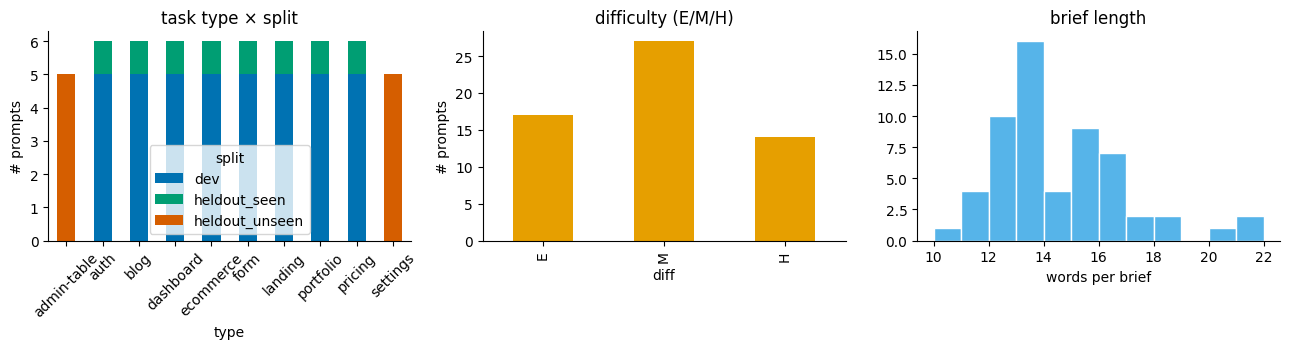

In [8]:
# Corpus EDA: type × split, difficulty, and brief-length distributions (config/prompts.yaml).
from p19 import prompts
P = pd.DataFrame(prompts.all_prompts())
P["n_words"] = P["text"].str.split().apply(len)
print("58 prompts |", P["split"].value_counts().to_dict())
print("brief length (words): mean %.1f  min %d  max %d" % (P.n_words.mean(), P.n_words.min(), P.n_words.max()))

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
ct = P.groupby(["type","split"]).size().unstack(fill_value=0)
ct = ct[[c for c in ["dev","heldout_seen","heldout_unseen"] if c in ct.columns]]
ct.plot(kind="bar", stacked=True, ax=ax[0], color=["#0072B2","#009E73","#D55E00"])
ax[0].set_title("task type × split"); ax[0].set_ylabel("# prompts"); ax[0].tick_params(axis="x", rotation=45)
P["diff"].value_counts().reindex(["E","M","H"]).plot(kind="bar", ax=ax[1], color="#E69F00")
ax[1].set_title("difficulty (E/M/H)"); ax[1].set_ylabel("# prompts")
ax[2].hist(P["n_words"], bins=12, color="#56B4E9", edgecolor="white")
ax[2].set_title("brief length"); ax[2].set_xlabel("words per brief")
for a in ax: a.spines[["top","right"]].set_visible(False)
fig.tight_layout(); plt.show()

In [9]:
# The leakage audit: zero style-word matches over the 58 briefs (PLAN §II.2 / PREREG §3).
leak = prompts.audit_prompt_leakage()
print("banned-word whole-word hits:", leak["hits"], "| thin briefs:", leak["thin_briefs"],
      "| PASS:", leak["pass"])

banned-word whole-word hits: [] | thin briefs: ['P06', 'PF03', 'PF04', 'PF06', 'B04', 'B05', 'E06', 'A03', 'A04', 'A05', 'A06', 'ST04'] | PASS: True


**Why these two OOD types.** The held-out **unseen** set is entirely **settings-panels (ST)** and
**admin-data-tables (AT)** — control-dense, information-dense layouts structurally unlike the
marketing- and content-oriented development types. They stress the skill's layout/hierarchy guidance
in a regime it was never tuned on, giving Stage-2 steering a genuine out-of-distribution
generalization test (RQ7). The split is frozen **by id** so the held-out set is touched exactly once.

---
**Next:** notebook **02** builds the objective half of the oracle on rendered fixtures; notebook **03**
builds the preference half.